In [1]:
# ==============================================================================
# MACHINE LEARNING ASSIGNMENT
# Clustering, Regression, and Classification with Dimensionality Reduction
# ==============================================================================

# --- 1. LIBRARIES AND CONFIGURATION ---
import os
import cv2  # OpenCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, silhouette_score

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Configuration
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
print(f"TensorFlow Version: {tf.__version__}")


# --- 2. HELPER FUNCTIONS ---

def train_autoencoder(X_train, X_test, encoding_dim, epochs=50, batch_size=32):
    """
    Trains a simple dense Autoencoder for dimensionality reduction.
    """
    input_dim = X_train.shape[1]

    # Encoder
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = layers.Dense(input_dim, activation='linear')(encoded)

    # Model
    autoencoder = models.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    print(f"\n[Autoencoder] Training (Input: {input_dim} -> Latent: {encoding_dim})...")
    history = autoencoder.fit(X_train, X_train,
                              epochs=epochs,
                              batch_size=batch_size,
                              shuffle=True,
                              validation_data=(X_test, X_test),
                              verbose=0)

    # Feature Extractor
    encoder = models.Model(input_layer, encoded)
    X_train_enc = encoder.predict(X_train, verbose=0)
    X_test_enc = encoder.predict(X_test, verbose=0)

    print(f"[Autoencoder] Training complete. Final Loss: {history.history['loss'][-1]:.4f}")
    return encoder, X_train_enc, X_test_enc

def apply_pca(X_train, X_test, n_components):
    """
    Applies PCA for dimensionality reduction.
    """
    print(f"\n[PCA] Applying reduction (Components: {n_components})...")
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    print(f"[PCA] Explained Variance Ratio: {np.sum(pca.explained_variance_ratio_):.4f}")
    return pca, X_train_pca, X_test_pca

TensorFlow Version: 2.19.0


In [2]:
# ==========================================
# PART 1: REGRESSION (Diamonds Dataset)
# ==========================================
print("\n" + "="*40)
print("PART 1: REGRESSION (Diamonds Dataset)")
print("="*40)

# Load Data
df_diamonds = sns.load_dataset('diamonds')
print(f"Dataset Shape: {df_diamonds.shape}")

# Preprocessing
categorical_cols = ['cut', 'color', 'clarity']
le = LabelEncoder()
for col in categorical_cols:
    df_diamonds[col] = le.fit_transform(df_diamonds[col])

X = df_diamonds.drop(columns=['price']).values
y = df_diamonds['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

# Dimensionality Reduction (Target: 3 features)
TARGET_DIM = 3
pca_model, X_train_pca, X_test_pca = apply_pca(X_train_scaled, X_test_scaled, n_components=TARGET_DIM)
encoder_model, X_train_ae, X_test_ae = train_autoencoder(X_train_scaled, X_test_scaled, encoding_dim=TARGET_DIM, epochs=30)

# FNN Training Function
def build_and_train_fnn(X_tr, y_tr, X_te, y_te, input_dim, name):
    print(f"\n[FNN] Training on {name} Data (Dim: {input_dim})...")
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    history = model.fit(X_tr, y_tr, epochs=20, batch_size=32, validation_data=(X_te, y_te), verbose=0)

    # Evaluation
    predictions_scaled = model.predict(X_te, verbose=0)
    predictions = scaler_y.inverse_transform(predictions_scaled)
    y_true = scaler_y.inverse_transform(y_te)

    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)
    print(f"[{name}] RMSE: ${rmse:.2f} | R2 Score: {r2:.4f}")
    return history, r2

# Training
hist_orig, r2_orig = build_and_train_fnn(X_train_scaled, y_train_scaled, X_test_scaled, y_test_scaled, 9, "ORIGINAL")
hist_pca, r2_pca = build_and_train_fnn(X_train_pca, y_train_scaled, X_test_pca, y_test_scaled, TARGET_DIM, "PCA")
hist_ae, r2_ae = build_and_train_fnn(X_train_ae, y_train_scaled, X_test_ae, y_test_scaled, TARGET_DIM, "AUTOENCODER")


PART 1: REGRESSION (Diamonds Dataset)
Dataset Shape: (53940, 10)

[PCA] Applying reduction (Components: 3)...
[PCA] Explained Variance Ratio: 0.7226

[Autoencoder] Training (Input: 9 -> Latent: 3)...
[Autoencoder] Training complete. Final Loss: 0.2782

[FNN] Training on ORIGINAL Data (Dim: 9)...
[ORIGINAL] RMSE: $592.01 | R2 Score: 0.9780

[FNN] Training on PCA Data (Dim: 3)...
[PCA] RMSE: $1578.82 | R2 Score: 0.8432

[FNN] Training on AUTOENCODER Data (Dim: 3)...
[AUTOENCODER] RMSE: $1613.60 | R2 Score: 0.8362



PART 2: CLUSTERING (Wine Quality)
Dataset Shape: (4898, 12)

[PCA] Applying reduction (Components: 2)...
[PCA] Explained Variance Ratio: 0.4377

[Autoencoder] Training (Input: 11 -> Latent: 2)...
[Autoencoder] Training complete. Final Loss: 0.5767

[K-Means] Running on ORIGINAL Data...
[ORIGINAL] Silhouette Score: 0.1478

[K-Means] Running on PCA Data...
[PCA] Silhouette Score: 0.3352


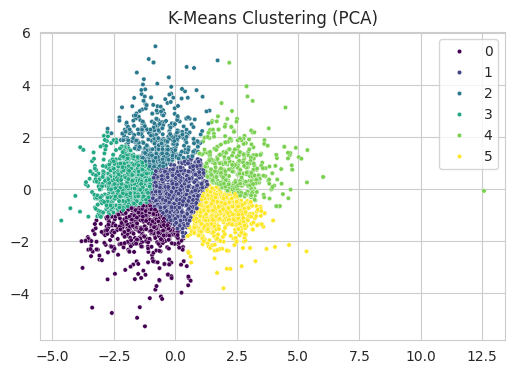


[K-Means] Running on AUTOENCODER Data...
[AUTOENCODER] Silhouette Score: 0.3445


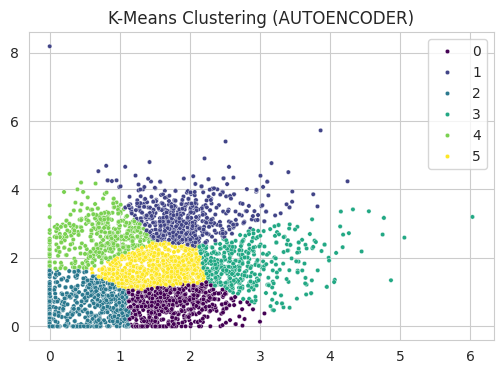

In [3]:
# ==========================================
# PART 2: CLUSTERING (Wine Quality Dataset)
# ==========================================
print("\n" + "="*40)
print("PART 2: CLUSTERING (Wine Quality)")
print("="*40)

# Load Data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"
df_wine = pd.read_csv(url, sep=';')
print(f"Dataset Shape: {df_wine.shape}")

X_wine = df_wine.drop(columns=['quality']).values
X_train_w, X_test_w = train_test_split(X_wine, test_size=0.2, random_state=42)

# Scaling
scaler_wine = StandardScaler()
X_train_w_scaled = scaler_wine.fit_transform(X_train_w)
X_test_w_scaled = scaler_wine.transform(X_test_w)

# Dimensionality Reduction (Target: 2 features)
CLUST_DIM = 2
pca_wine, X_train_pca_w, X_test_pca_w = apply_pca(X_train_w_scaled, X_test_w_scaled, n_components=CLUST_DIM)
enc_wine, X_train_ae_w, X_test_ae_w = train_autoencoder(X_train_w_scaled, X_test_w_scaled, encoding_dim=CLUST_DIM, epochs=40)

# K-Means Training Function
def train_evaluate_kmeans(X_data, n_clusters, name):
    print(f"\n[K-Means] Running on {name} Data...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_data)

    sil_score = silhouette_score(X_data, labels)
    print(f"[{name}] Silhouette Score: {sil_score:.4f}")

    if X_data.shape[1] == 2:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=X_data[:, 0], y=X_data[:, 1], hue=labels, palette='viridis', s=10)
        plt.title(f'K-Means Clustering ({name})')
        plt.show()

# Training
K_CLUSTERS = 6
train_evaluate_kmeans(X_train_w_scaled, K_CLUSTERS, "ORIGINAL")
train_evaluate_kmeans(X_train_pca_w, K_CLUSTERS, "PCA")
train_evaluate_kmeans(X_train_ae_w, K_CLUSTERS, "AUTOENCODER")


PART 3: CLASSIFICATION (GTZAN Spectrograms)
Cloning repository from https://github.com/screamkface/Repo-for-gtzan-dataset.git...
Repository cloned.
Images found at: /content/Repo-for-gtzan-dataset/images_original
Loading and resizing images...
Classes found: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Loaded 999 images. Shape: (999, 64, 64)

[PCA] Applying reduction (Components: 128)...
[PCA] Explained Variance Ratio: 0.6924

[Autoencoder] Training (Input: 4096 -> Latent: 128)...
[Autoencoder] Training complete. Final Loss: 0.0056

[CNN] Training on Original Images...
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.1168 - loss: 2.3138 - val_accuracy: 0.2450 - val_loss: 2.2229
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2421 - loss: 2.1516 - val_accuracy: 0.2700 - val_loss: 1.9900
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3071 - loss: 1.9195 - val_accuracy: 0.3650 - val_loss: 

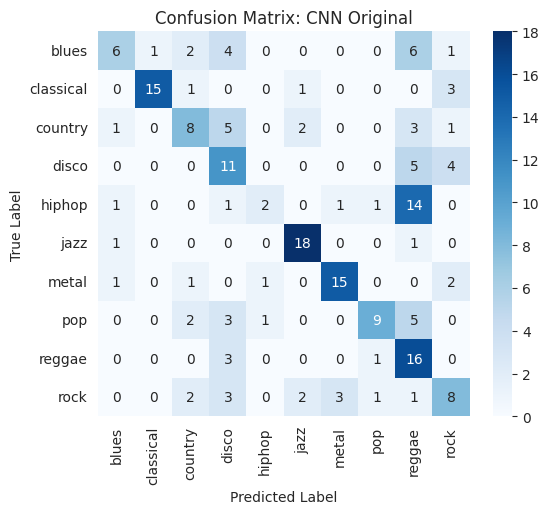


[Dense] Training on PCA Reduced Data...

--- Evaluation: PCA Reduced ---
              precision    recall  f1-score   support

       blues       0.40      0.40      0.40        20
   classical       0.60      0.60      0.60        20
     country       0.46      0.30      0.36        20
       disco       0.29      0.25      0.27        20
      hiphop       0.38      0.30      0.33        20
        jazz       0.46      0.30      0.36        20
       metal       0.64      0.80      0.71        20
         pop       0.47      0.40      0.43        20
      reggae       0.39      0.60      0.47        20
        rock       0.25      0.35      0.29        20

    accuracy                           0.43       200
   macro avg       0.43      0.43      0.42       200
weighted avg       0.43      0.43      0.42       200



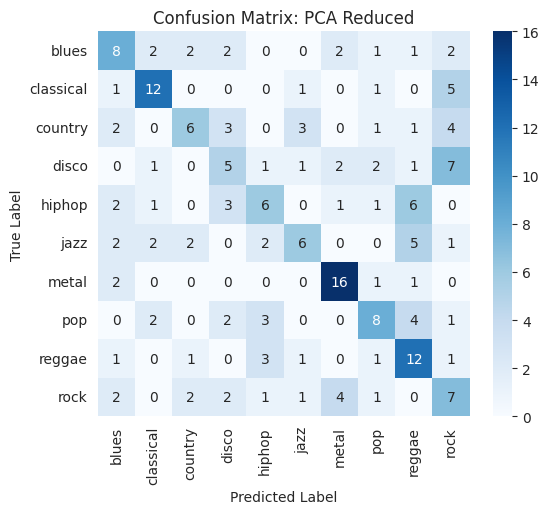


[Dense] Training on Autoencoder Reduced Data...

--- Evaluation: Autoencoder Reduced ---


              precision    recall  f1-score   support

       blues       0.00      0.00      0.00        20
   classical       0.25      0.70      0.37        20
     country       0.20      0.50      0.29        20
       disco       0.00      0.00      0.00        20
      hiphop       0.00      0.00      0.00        20
        jazz       0.00      0.00      0.00        20
       metal       0.34      0.60      0.44        20
         pop       0.00      0.00      0.00        20
      reggae       0.16      0.30      0.21        20
        rock       0.11      0.10      0.11        20

    accuracy                           0.22       200
   macro avg       0.11      0.22      0.14       200
weighted avg       0.11      0.22      0.14       200



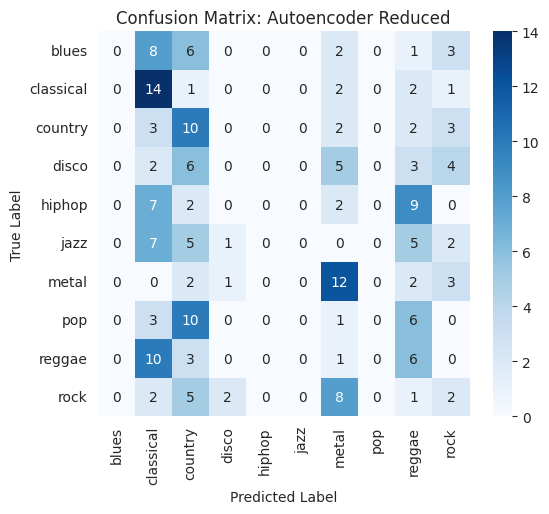


=== CLASSIFICATION SUMMARY ===
CNN Original Accuracy: 0.5400
PCA Dense Accuracy:    0.4300
AE Dense Accuracy:     0.2200


In [4]:
# ==========================================
# PART 3: CLASSIFICATION (GTZAN Dataset)
# ==========================================
print("\n" + "="*40)
print("PART 3: CLASSIFICATION (GTZAN Spectrograms)")
print("="*40)

# Setup Data Repository
REPO_URL = "https://github.com/screamkface/Repo-for-gtzan-dataset.git"
REPO_DIR = "/content/Repo-for-gtzan-dataset"
DATASET_PATH = os.path.join(REPO_DIR, "Data", "images_original")

if not os.path.exists(REPO_DIR):
    print(f"Cloning repository from {REPO_URL}...")
    # NOTE: This command works in Google Colab / Jupyter environment
    os.system(f"git clone {REPO_URL}")
    print("Repository cloned.")
else:
    print("Repository already exists.")

# Check path
if not os.path.exists(DATASET_PATH):
    # Fallback search
    for root, dirs, files in os.walk(REPO_DIR):
        if "images_original" in dirs:
            DATASET_PATH = os.path.join(root, "images_original")
            break
    print(f"Images found at: {DATASET_PATH}")

IMG_HEIGHT = 64
IMG_WIDTH = 64

# Load Images
def load_images_from_folder(folder_path):
    images = []
    labels = []

    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found at: {folder_path}")

    class_names = sorted([d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))])
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"Classes found: {class_names}")

    for class_name in class_names:
        class_dir = os.path.join(folder_path, class_name)
        for filename in os.listdir(class_dir):
            if filename.endswith(('.png', '.jpg')):
                img_path = os.path.join(class_dir, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                    images.append(img)
                    labels.append(class_map[class_name])

    return np.array(images), np.array(labels), class_names

print("Loading and resizing images...")
try:
    X_img, y_img, class_names = load_images_from_folder(DATASET_PATH)
    print(f"Loaded {X_img.shape[0]} images. Shape: {X_img.shape}")
except Exception as e:
    print(f"Error loading images: {e}")
    raise

# Preprocessing
X_img = X_img.astype('float32') / 255.0
X_train_img, X_test_img, y_train_img, y_test_img = train_test_split(
    X_img, y_img, test_size=0.2, stratify=y_img, random_state=42
)

num_classes = len(class_names)
y_train_cat = to_categorical(y_train_img, num_classes)
y_test_cat = to_categorical(y_test_img, num_classes)

# Dimensionality Reduction Preparation
X_train_flat = X_train_img.reshape(X_train_img.shape[0], -1)
X_test_flat = X_test_img.reshape(X_test_img.shape[0], -1)

IMG_LATENT_DIM = 128

# Apply PCA and Autoencoder
pca_img, X_train_pca_img, X_test_pca_img = apply_pca(X_train_flat, X_test_flat, n_components=IMG_LATENT_DIM)
enc_img, X_train_ae_img, X_test_ae_img = train_autoencoder(X_train_flat, X_test_flat, encoding_dim=IMG_LATENT_DIM, epochs=20)

# Evaluation Function
def evaluate_classifier(model, X_test, y_test_cat, class_names, title):
    print(f"\n--- Evaluation: {title} ---")
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    loss, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    return acc

# 1. CNN (Original Images)
print("\n[CNN] Training on Original Images...")
X_train_cnn = X_train_img.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
X_test_cnn = X_test_img.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_hist = cnn_model.fit(X_train_cnn, y_train_cat, epochs=15, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

acc_cnn = evaluate_classifier(cnn_model, X_test_cnn, y_test_cat, class_names, "CNN Original")

# 2. Dense Classifier (Reduced Data)
def train_dense_classifier(X_tr, y_tr, X_te, y_te, name):
    print(f"\n[Dense] Training on {name} Data...")
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(X_tr.shape[1],)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_tr, y_tr, epochs=20, batch_size=32, validation_data=(X_te, y_te), verbose=0)
    return evaluate_classifier(model, X_te, y_te, class_names, name)

acc_pca = train_dense_classifier(X_train_pca_img, y_train_cat, X_test_pca_img, y_test_cat, "PCA Reduced")
acc_ae = train_dense_classifier(X_train_ae_img, y_train_cat, X_test_ae_img, y_test_cat, "Autoencoder Reduced")

print(f"\n=== CLASSIFICATION SUMMARY ===")
print(f"CNN Original Accuracy: {acc_cnn:.4f}")
print(f"PCA Dense Accuracy:    {acc_pca:.4f}")
print(f"AE Dense Accuracy:     {acc_ae:.4f}")


PART 4: LEARNING CURVES


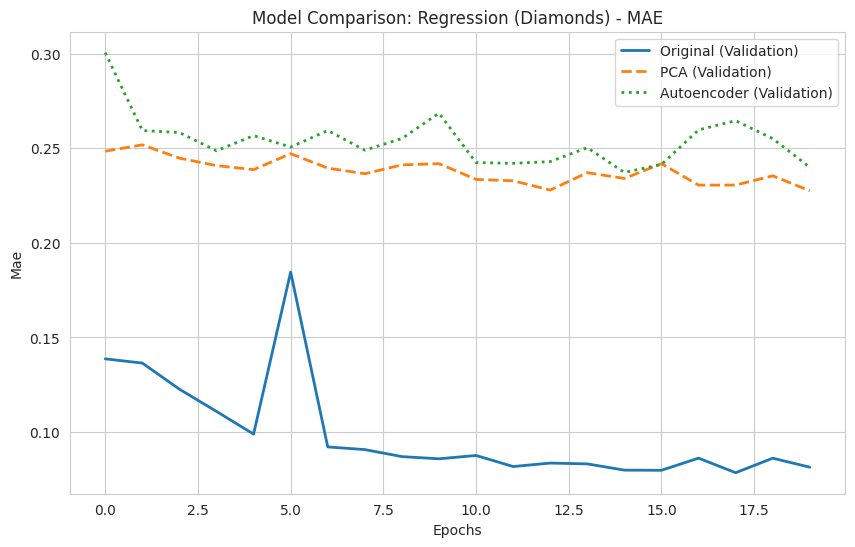

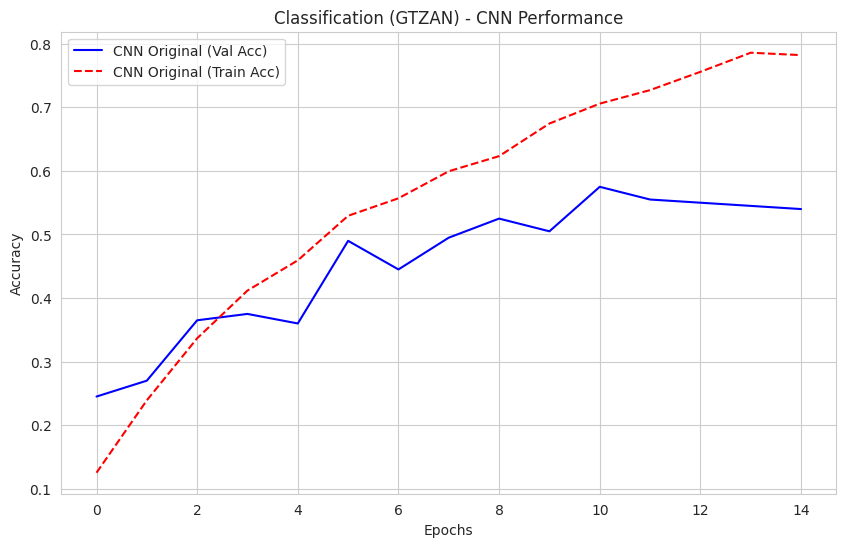

In [5]:
# ==========================================
# PART 4: VISUALIZATION
# ==========================================
print("\n" + "="*40)
print("PART 4: LEARNING CURVES")
print("="*40)

def plot_comparison(history_orig, history_pca, history_ae, metric, title):
    plt.figure(figsize=(10, 6))

    val_metric = f'val_{metric}'
    if history_orig:
        plt.plot(history_orig.history[val_metric], label='Original (Validation)', linestyle='-', linewidth=2)
    if history_pca:
        plt.plot(history_pca.history[val_metric], label='PCA (Validation)', linestyle='--', linewidth=2)
    if history_ae:
        plt.plot(history_ae.history[val_metric], label='Autoencoder (Validation)', linestyle=':', linewidth=2)

    plt.title(f'Model Comparison: {title}')
    plt.xlabel('Epochs')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.show()

# Regression Curves
if 'hist_orig' in locals():
    plot_comparison(hist_orig, hist_pca, hist_ae, 'mae', 'Regression (Diamonds) - MAE')

# Classification Curves
if 'cnn_hist' in locals():
    plt.figure(figsize=(10, 6))
    plt.plot(cnn_hist.history['val_accuracy'], label='CNN Original (Val Acc)', color='blue')
    plt.plot(cnn_hist.history['accuracy'], label='CNN Original (Train Acc)', color='red', linestyle='--')
    plt.title('Classification (GTZAN) - CNN Performance')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()